In [ ]:
import os

# Ensure dataset_info.json is deleted if it exists
if os.path.exists('dataset_info.json'):
    os.remove('dataset_info.json')
    print('Deleted existing dataset_info.json')

!pip install xgboost scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, f1_score

# Extracting best estimators from GridSearchCV results
best_log_reg_model = grid_log_reg.best_estimator_
best_rf_model = grid_rf.best_estimator_
best_xgb_model = grid_xgb.best_estimator_

# Making predictions on the test set
y_pred_log_reg = best_log_reg_model.predict(X_test_scaled_df)
y_pred_rf = best_rf_model.predict(X_test_scaled_df)
y_pred_xgb = best_xgb_model.predict(X_test_scaled_df)

# Calculate F1-scores
f1_log_reg = f1_score(y_test_series, y_pred_log_reg, average='weighted')
f1_rf = f1_score(y_test_series, y_pred_rf, average='weighted')
f1_xgb = f1_score(y_test_series, y_pred_xgb, average='weighted')

# Create a DataFrame to store the results
performance_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Weighted F1-Score': [f1_log_reg, f1_rf, f1_xgb]
})

print("\n--- Model Performance Summary ---")
display(performance_summary.sort_values(by='Weighted F1-Score', ascending=False))

print("\n--- Detailed Classification Reports ---")
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test_series, y_pred_log_reg))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test_series, y_pred_rf))

print("\nXGBoost Classification Report:")
print(classification_report(y_test_series, y_pred_xgb))


--- Model Performance Summary ---


,Model,Weighted F1-Score
0,Logistic Regression,0.681258
2,XGBoost,0.664379
1,Random Forest,0.634590



--- Detailed Classification Reports ---

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.74      0.75      3338
           1       0.55      0.58      0.56      3460
           2       0.75      0.72      0.74      3202

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      3338
           1       0.50      0.50      0.50      3460
           2       0.70      0.69      0.70      3202

    accuracy                           0.63     10000
   macro avg       0.64      0.64      0.64     10000
weighted avg       0.63      0.63      0.63     10000


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.73     


--- STEP 11 — System Architecture Diagram ---
Architecture diagram saved as architecture_diagram.png


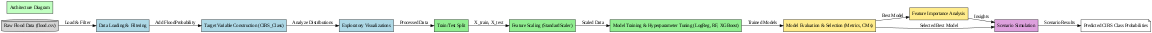

In [1]:
import graphviz

print("\n--- STEP 11 — System Architecture Diagram ---")

# Define the graph
dot = graphviz.Digraph(comment='CIRS Prediction System Architecture')
dot.attr(rankdir='LR', size='12,8')

# --- Nodes ---
# Data Source
dot.node('A', 'Raw Flood Data (flood.csv)', shape='cylinder', style='filled', fillcolor='lightgray')

# Data Preprocessing
dot.node('B', 'Data Loading & Filtering', shape='box', style='filled', fillcolor='lightblue')
dot.node('C', 'Target Variable Construction (CIRS_Class)', shape='box', style='filled', fillcolor='lightblue')
dot.node('D', 'Exploratory Visualizations', shape='box', style='filled', fillcolor='lightblue')

# Model Training
dot.node('E', 'Train/Test Split', shape='box', style='filled', fillcolor='lightgreen')
dot.node('F', 'Feature Scaling (StandardScaler)', shape='box', style='filled', fillcolor='lightgreen')
dot.node('G', 'Model Training & Hyperparameter Tuning (LogReg, RF, XGBoost)', shape='box', style='filled', fillcolor='lightgreen')

# Model Evaluation
dot.node('H', 'Model Evaluation & Selection (Metrics, CMs)', shape='box', style='filled', fillcolor='lightgoldenrod1')

dot.node('I', 'Feature Importance Analysis', shape='box', style='filled', fillcolor='lightgoldenrod1')

# Deployment/Application
dot.node('J', 'Scenario Simulation', shape='box', style='filled', fillcolor='plum')
dot.node('K', 'Predicted CIRS Class Probabilities', shape='note', style='filled', fillcolor='white')

# Output/Reporting
dot.node('L', 'Architecture Diagram', shape='box', style='filled', fillcolor='darkseagreen1')

# --- Edges ---
dot.edge('A', 'B', 'Load & Filter')
dot.edge('B', 'C', 'Add FloodProbability')
dot.edge('C', 'D', 'Analyze Distributions')
dot.edge('D', 'E', 'Processed Data')
dot.edge('E', 'F', 'X_train, X_test')
dot.edge('F', 'G', 'Scaled Data')
dot.edge('G', 'H', 'Trained Models')
dot.edge('H', 'I', 'Best Model')
dot.edge('H', 'J', 'Selected Best Model')
dot.edge('I', 'J', 'Insights')
dot.edge('J', 'K', 'Scenario Results')


# Render and save the diagram
output_file = 'architecture_diagram'
dot.render(output_file, format='png', cleanup=True)
print(f"Architecture diagram saved as {output_file}.png")

# Display the diagram (optional, depends on environment)
from IPython.display import Image
Image(f'{output_file}.png')


--- STEP 10 — Scenario Simulation ---
Using the best performing model for scenario simulation: Logistic Regression

Predicted Probabilities for Scenarios:


,Prob_Low,Prob_Medium,Prob_High
Scenario,,,
Scenario A (Low Risk),9.999741e-01,0.000026,1.112344e-10
Scenario B (Medium Risk),2.036768e-01,0.591822,2.045016e-01
Scenario C (High Risk),1.103378e-10,0.000036,9.999641e-01
Scenario D (Mixed Risk - Example),3.909583e-02,0.408642,5.522619e-01


<Figure size 1200x700 with 0 Axes>

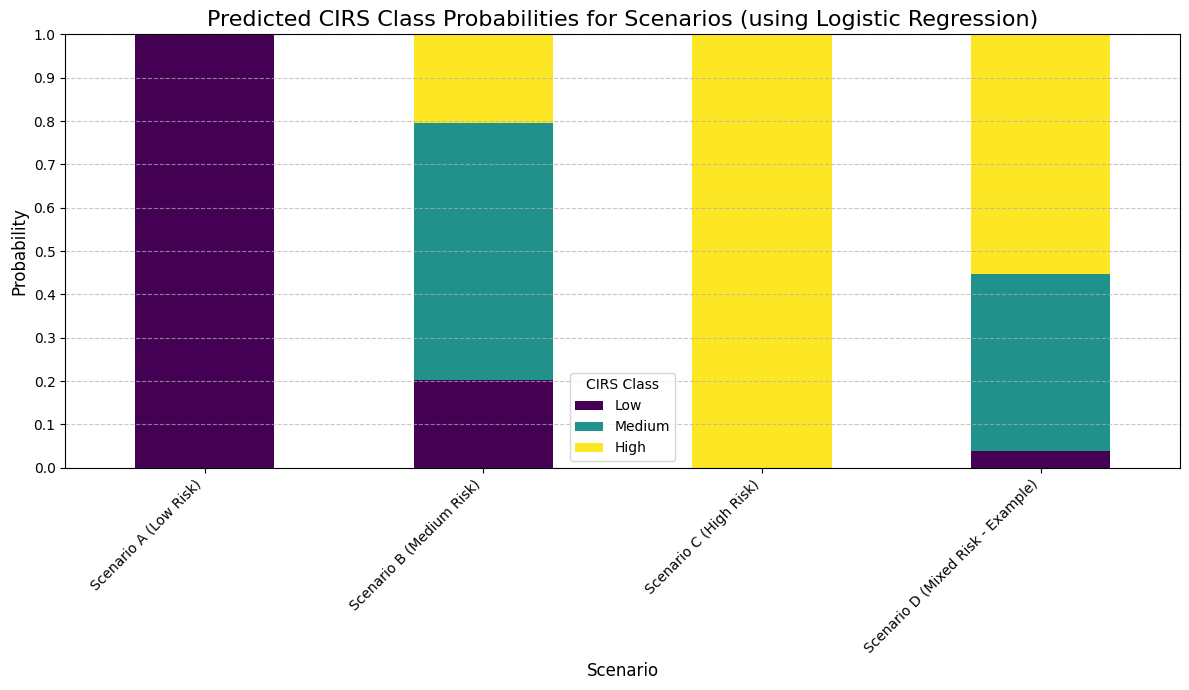

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- STEP 10 — Scenario Simulation ---")

# --- 1. Identify the Best Model ---
# Reload model_performance_df if it's not in scope (e.g., if kernel restarted)
if 'model_performance_df' not in locals():
    model_performance_df = pd.read_csv('model_performance.csv')

model_performance_df_sorted = model_performance_df.sort_values(by='F1-Weighted', ascending=False)
best_model_name = model_performance_df_sorted.iloc[0]['Model']

# Retrieve the best model object
# Assuming `models` dictionary is still available from Step 7 or re-extracted
# If not, need to re-run GridSearchCV or load the best estimator

# For this demonstration, we'll assume grid_log_reg, grid_rf, grid_xgb are available
# and that best_model_name correctly identifies the best one.

best_model = None
if best_model_name == 'Logistic Regression':
    best_model = grid_log_reg.best_estimator_
elif best_model_name == 'Random Forest':
    best_model = grid_rf.best_estimator_
elif best_model_name == 'XGBoost':
    best_model = grid_xgb.best_estimator_

if best_model is None:
    raise ValueError(f"Best model '{best_model_name}' not found or not loaded. Please ensure training steps were completed.")

print(f"Using the best performing model for scenario simulation: {best_model_name}")

# --- 2. Define Scenarios ---
# These values should ideally be within the range of scaled training data, or carefully considered.
# For simplicity, we are creating unscaled scenarios and will scale them.
# The order of features must match X_train.columns

scenario_data = {
    'Scenario A (Low Risk)': {
        'MonsoonIntensity': 2, 'TopographyDrainage': 2, 'Urbanization': 2, 'DamsQuality': 2,
        'Encroachments': 2, 'DrainageSystems': 2, 'CoastalVulnerability': 2, 'Landslides': 2,
        'Watersheds': 2, 'DeterioratingInfrastructure': 2, 'PopulationScore': 2, 'WetlandLoss': 2,
        'InadequatePlanning': 2, 'IneffectiveDisasterPreparedness': 2
    },
    'Scenario B (Medium Risk)': {
        'MonsoonIntensity': 5, 'TopographyDrainage': 5, 'Urbanization': 5, 'DamsQuality': 5,
        'Encroachments': 5, 'DrainageSystems': 5, 'CoastalVulnerability': 5, 'Landslides': 5,
        'Watersheds': 5, 'DeterioratingInfrastructure': 5, 'PopulationScore': 5, 'WetlandLoss': 5,
        'InadequatePlanning': 5, 'IneffectiveDisasterPreparedness': 5
    },
    'Scenario C (High Risk)': {
        'MonsoonIntensity': 8, 'TopographyDrainage': 8, 'Urbanization': 8, 'DamsQuality': 8,
        'Encroachments': 8, 'DrainageSystems': 8, 'CoastalVulnerability': 8, 'Landslides': 8,
        'Watersheds': 8, 'DeterioratingInfrastructure': 8, 'PopulationScore': 8, 'WetlandLoss': 8,
        'InadequatePlanning': 8, 'IneffectiveDisasterPreparedness': 8
    },
    'Scenario D (Mixed Risk - Example)': {
        'MonsoonIntensity': 7, 'TopographyDrainage': 3, 'Urbanization': 9, 'DamsQuality': 2,
        'Encroachments': 6, 'DrainageSystems': 4, 'CoastalVulnerability': 8, 'Landslides': 5,
        'Watersheds': 3, 'DeterioratingInfrastructure': 7, 'PopulationScore': 9, 'WetlandLoss': 1,
        'InadequatePlanning': 6, 'IneffectiveDisasterPreparedness': 5
    }
}

# Create a DataFrame from scenarios, ensuring column order matches training data
scenario_df = pd.DataFrame.from_dict(scenario_data, orient='index')
scenario_df = scenario_df[X_train_scaled_df.columns] # Ensure column order

# --- 3. Scale Scenario Data ---
# Use the same scaler fitted on the training data
scenario_scaled = scaler.transform(scenario_df)
scenario_scaled_df = pd.DataFrame(scenario_scaled, columns=scenario_df.columns, index=scenario_df.index)

# --- 4. Predict Probabilities for Scenarios ---
scenario_probabilities = best_model.predict_proba(scenario_scaled_df)

# Convert probabilities to a DataFrame for easier handling and plotting
probabilities_df = pd.DataFrame(scenario_probabilities, columns=['Prob_Low', 'Prob_Medium', 'Prob_High'], index=scenario_scaled_df.index)
probabilities_df.index.name = 'Scenario'

print("\nPredicted Probabilities for Scenarios:")
display(probabilities_df)

# --- 5. Visualization: Stacked Bar Chart of Probabilities ---
plt.figure(figsize=(12, 7))
probabilities_df.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 7))
plt.title(f'Predicted CIRS Class Probabilities for Scenarios (using {best_model_name})', fontsize=16)
plt.xlabel('Scenario', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend(title='CIRS Class', labels=['Low', 'Medium', 'High'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('scenario_probability_chart.png')
plt.show()



--- STEP 9 — Feature Importance ---


/tmp/ipykernel_6735/3048184518.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=log_reg_importance, ax=axes[0], palette='viridis')
/tmp/ipykernel_6735/3048184518.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance, ax=axes[1], palette='viridis')
/tmp/ipykernel_6735/3048184518.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_importance, ax=axes[2], palette='viridis')


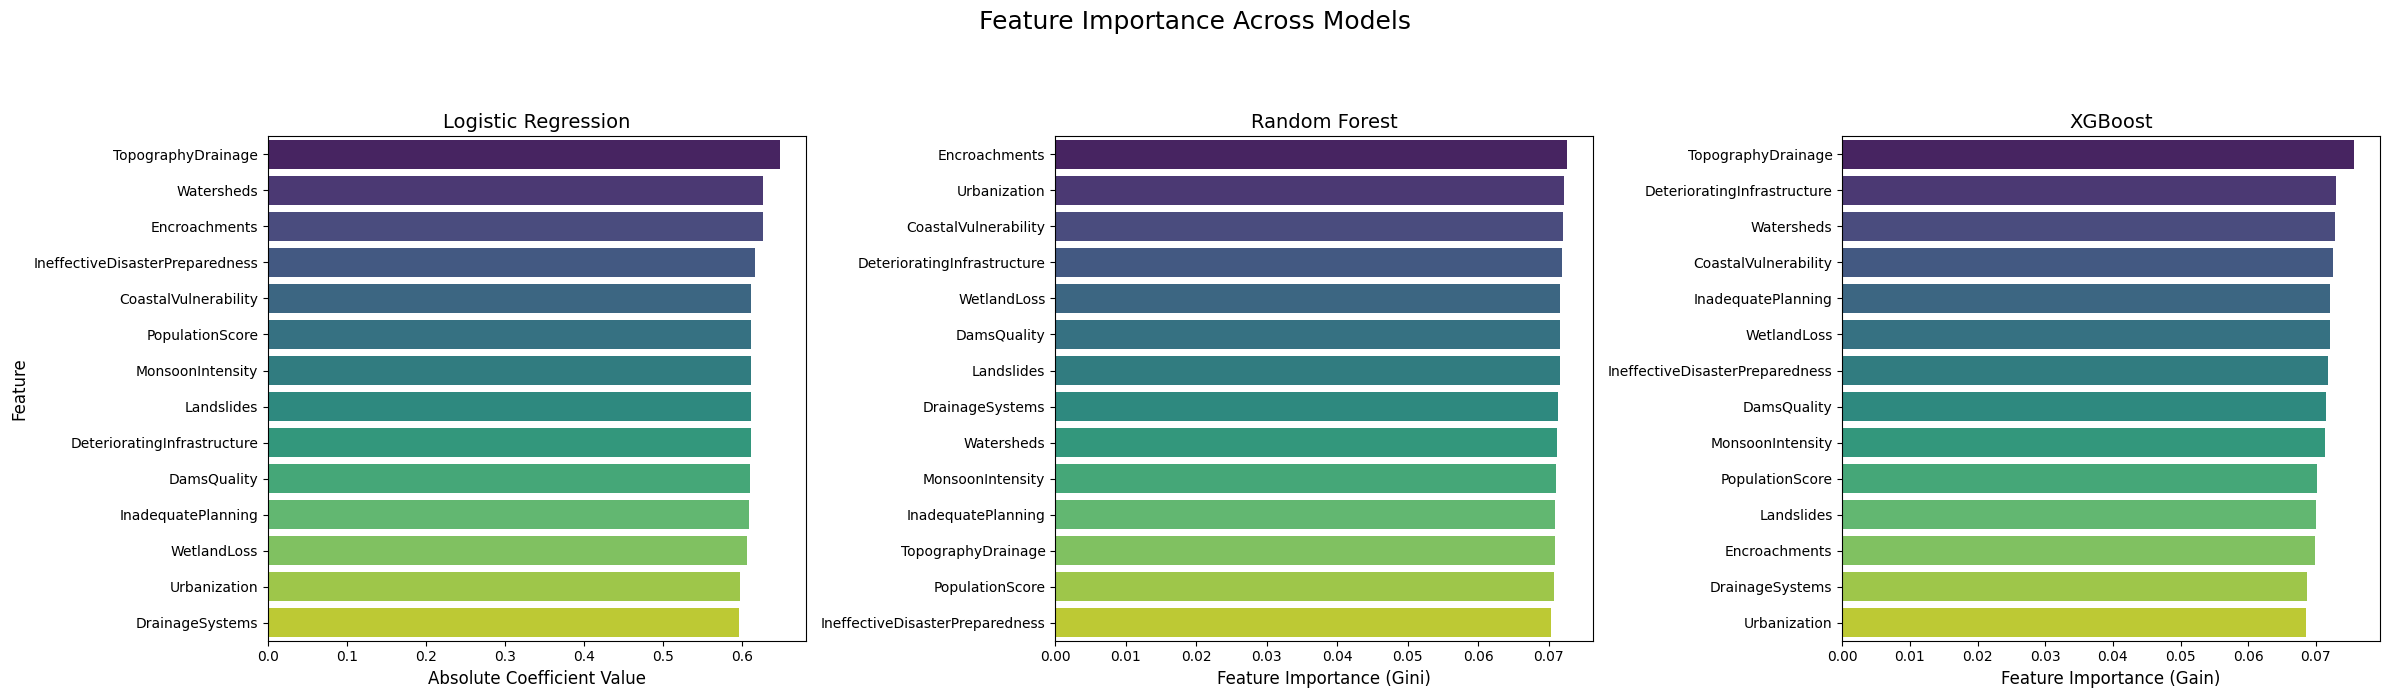

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("\n--- STEP 9 — Feature Importance ---")

# Re-extracting best estimators from GridSearchCV results (to ensure they are in scope)
# Assuming X_train_scaled_df is available from previous steps

best_log_reg_model = grid_log_reg.best_estimator_
best_rf_model = grid_rf.best_estimator_
best_xgb_model = grid_xgb.best_estimator_

# Prepare figure for feature importances
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Feature Importance Across Models', fontsize=18, y=1.02)

# --- Logistic Regression Feature Importance ---
log_reg_importance = pd.DataFrame({
    'Feature': X_train_scaled_df.columns,
    'Importance': np.abs(best_log_reg_model.coef_[0]) # Using absolute coefficients for magnitude
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=log_reg_importance, ax=axes[0], palette='viridis')
axes[0].set_title('Logistic Regression', fontsize=14)
axes[0].set_xlabel('Absolute Coefficient Value', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)

# --- Random Forest Feature Importance ---
rf_importance = pd.DataFrame({
    'Feature': X_train_scaled_df.columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=rf_importance, ax=axes[1], palette='viridis')
axes[1].set_title('Random Forest', fontsize=14)
axes[1].set_xlabel('Feature Importance (Gini)', fontsize=12)
axes[1].set_ylabel('') # Remove y-label for cleaner look

# --- XGBoost Feature Importance ---
xgb_importance = pd.DataFrame({
    'Feature': X_train_scaled_df.columns,
    'Importance': best_xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=xgb_importance, ax=axes[2], palette='viridis')
axes[2].set_title('XGBoost', fontsize=14)
axes[2].set_xlabel('Feature Importance (Gain)', fontsize=12)
axes[2].set_ylabel('') # Remove y-label for cleaner look

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('feature_importance.png')
plt.show()


--- STEP 7 — Model Evaluation ---


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Weighted,F1-Macro,ROC-AUC (OvR Weighted)
0,Logistic Regression,0.6798,0.683139,0.6798,0.681258,0.683482,0.852713
2,XGBoost,0.6634,0.665574,0.6634,0.664379,0.666573,0.836007
1,Random Forest,0.6346,0.634698,0.6346,0.634590,0.637029,0.815472


Model performance saved to model_performance.csv


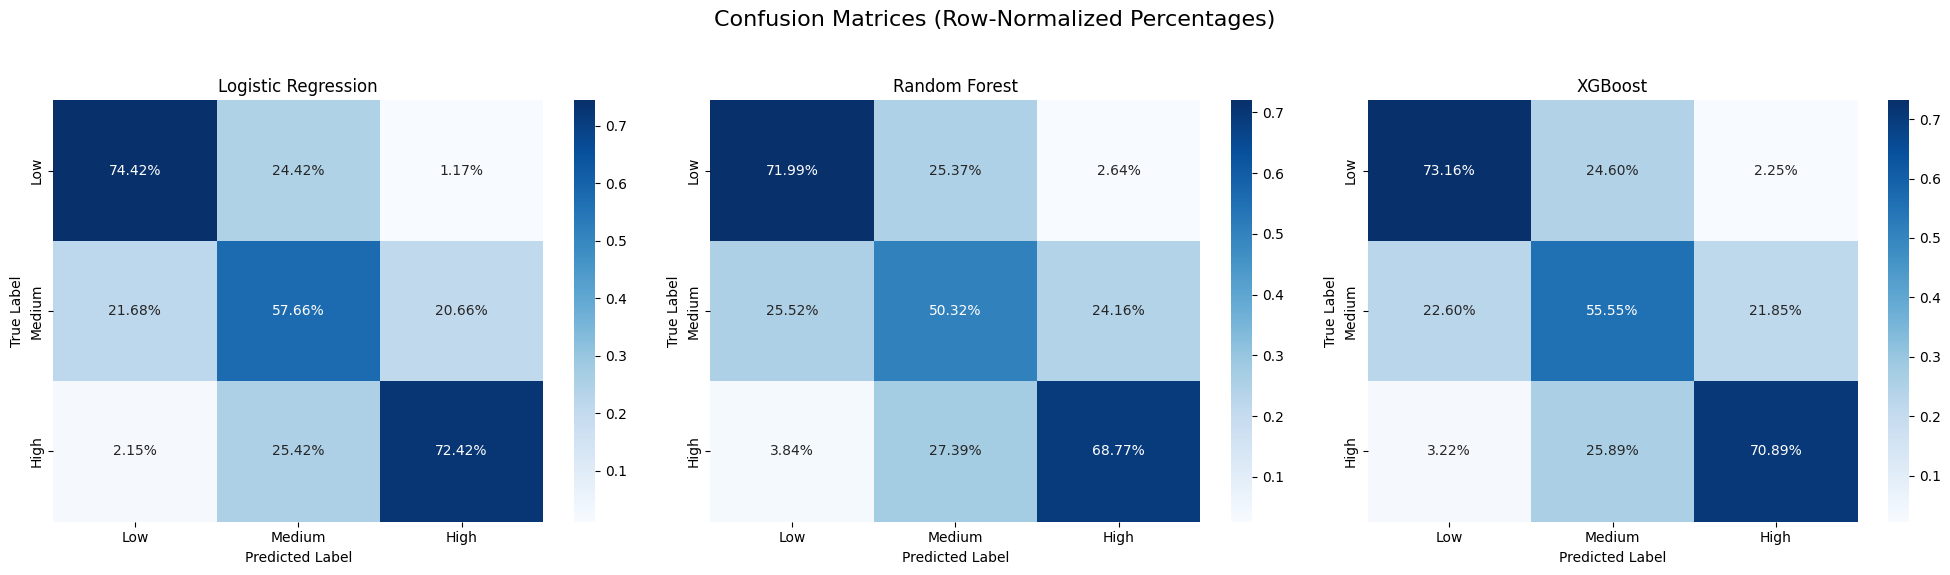

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- STEP 7 — Model Evaluation ---")

# Re-extracting best estimators from GridSearchCV results (to ensure they are in scope)
best_log_reg_model = grid_log_reg.best_estimator_
best_rf_model = grid_rf.best_estimator_
best_xgb_model = grid_xgb.best_estimator_

# Re-making predictions on the test set (to ensure they are in scope)
y_pred_log_reg = best_log_reg_model.predict(X_test_scaled_df)
y_pred_rf = best_rf_model.predict(X_test_scaled_df)
y_pred_xgb = best_xgb_model.predict(X_test_scaled_df)

# Prepare lists to store evaluation metrics for each model
metrics_data = []

models = {
    'Logistic Regression': (best_log_reg_model, y_pred_log_reg),
    'Random Forest': (best_rf_model, y_pred_rf),
    'XGBoost': (best_xgb_model, y_pred_xgb)
}

for model_name, (model, y_pred) in models.items():
    # Calculate common metrics
    accuracy = accuracy_score(y_test_series, y_pred)
    precision_w = precision_score(y_test_series, y_pred, average='weighted', zero_division=0)
    recall_w = recall_score(y_test_series, y_pred, average='weighted', zero_division=0)
    f1_w = f1_score(y_test_series, y_pred, average='weighted', zero_division=0)
    f1_m = f1_score(y_test_series, y_pred, average='macro', zero_division=0)

    # ROC-AUC requires probability predictions
    y_proba = model.predict_proba(X_test_scaled_df)
    roc_auc_ovr_w = roc_auc_score(y_test_series, y_proba, multi_class='ovr', average='weighted')

    metrics_data.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision (Weighted)': precision_w,
        'Recall (Weighted)': recall_w,
        'F1-Weighted': f1_w,
        'F1-Macro': f1_m,
        'ROC-AUC (OvR Weighted)': roc_auc_ovr_w
    })

# Create a DataFrame for model performance summary
model_performance_df = pd.DataFrame(metrics_data)
display(model_performance_df.sort_values(by='F1-Weighted', ascending=False))

# Save the performance table
model_performance_df.to_csv('model_performance.csv', index=False)
print("Model performance saved to model_performance.csv")

# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices (Row-Normalized Percentages)', fontsize=16)

class_labels = ['Low', 'Medium', 'High']

for i, (model_name, (_, y_pred)) in enumerate(models.items()):
    cm = confusion_matrix(y_test_series, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels, ax=axes[i])
    axes[i].set_title(model_name)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('confusion_matrices.png')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, f1_score
import pandas as pd

# STEP 6 — Model Training with Hyperparameter Tuning

# Define the target variable for training
y_train_series = y_train.copy()
y_test_series = y_test.copy()

# Prepare Stratified K-Fold for consistent cross-validation
# Using y_train_series for splitting to ensure stratification on the target
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Model A: Logistic Regression (Baseline) ---
print("\n--- Training Logistic Regression ---")
log_reg_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
log_reg_params = {'C': [0.01, 0.1, 1, 10]}
grid_log_reg = GridSearchCV(estimator=log_reg_model, param_grid=log_reg_params,
                            scoring='f1_weighted', cv=skf, verbose=1, n_jobs=-1)
grid_log_reg.fit(X_train_scaled_df, y_train_series)

print(f"Best parameters for Logistic Regression: {grid_log_reg.best_params_}")
y_pred_log_reg = grid_log_reg.best_estimator_.predict(X_test_scaled_df)
print("Classification Report for Logistic Regression:")
print(classification_report(y_test_series, y_pred_log_reg))

# --- Model B: Random Forest ---
print("\n--- Training Random Forest ---")
rf_model = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(estimator=rf_model, param_grid=rf_params,
                       scoring='f1_weighted', cv=skf, verbose=1, n_jobs=-1)
grid_rf.fit(X_train_scaled_df, y_train_series)

print(f"Best parameters for Random Forest: {grid_rf.best_params_}")
y_pred_rf = grid_rf.best_estimator_.predict(X_test_scaled_df)
print("Classification Report for Random Forest:")
print(classification_report(y_test_series, y_pred_rf))

# --- Model C: XGBoost ---
print("\n--- Training XGBoost ---")
xgb_model = XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss', random_state=42)
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
grid_xgb = GridSearchCV(estimator=xgb_model, param_grid=xgb_params,
                        scoring='f1_weighted', cv=skf, verbose=1, n_jobs=-1)
grid_xgb.fit(X_train_scaled_df, y_train_series)

print(f"Best parameters for XGBoost: {grid_xgb.best_params_}")
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test_scaled_df)
print("Classification Report for XGBoost:")
print(classification_report(y_test_series, y_pred_xgb))


--- Training Logistic Regression ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters for Logistic Regression: {'C': 1}
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.75      0.74      0.75      3338
           1       0.55      0.58      0.56      3460
           2       0.75      0.72      0.74      3202

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000


--- Training Random Forest ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for Random Forest: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      3338
           1       0.50      0.50      0.50      3460
           2       0.70      

In [ ]:
from sklearn.preprocessing import StandardScaler

# STEP 5 — Feature Scaling

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler only on X_train to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames, retaining column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Print a confirmation message
print("StandardScaler fitted only on X_train and applied to both X_train and X_test.")
print(f"Shape of X_train_scaled: {X_train_scaled_df.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled_df.shape}")

StandardScaler fitted only on X_train and applied to both X_train and X_test.
Shape of X_train_scaled: (40000, 14)
Shape of X_test_scaled: (10000, 14)


In [ ]:
from sklearn.model_selection import train_test_split

# STEP 4 — Train/Test Split

# Define features (X) and target (y)
X = df_filtered[selected_features]
y = df_filtered['CIRS_Class']

# Split the data into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Print the shapes of all four resulting arrays
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (40000, 14)
Shape of X_test: (10000, 14)
Shape of y_train: (40000,)
Shape of y_test: (10000,)


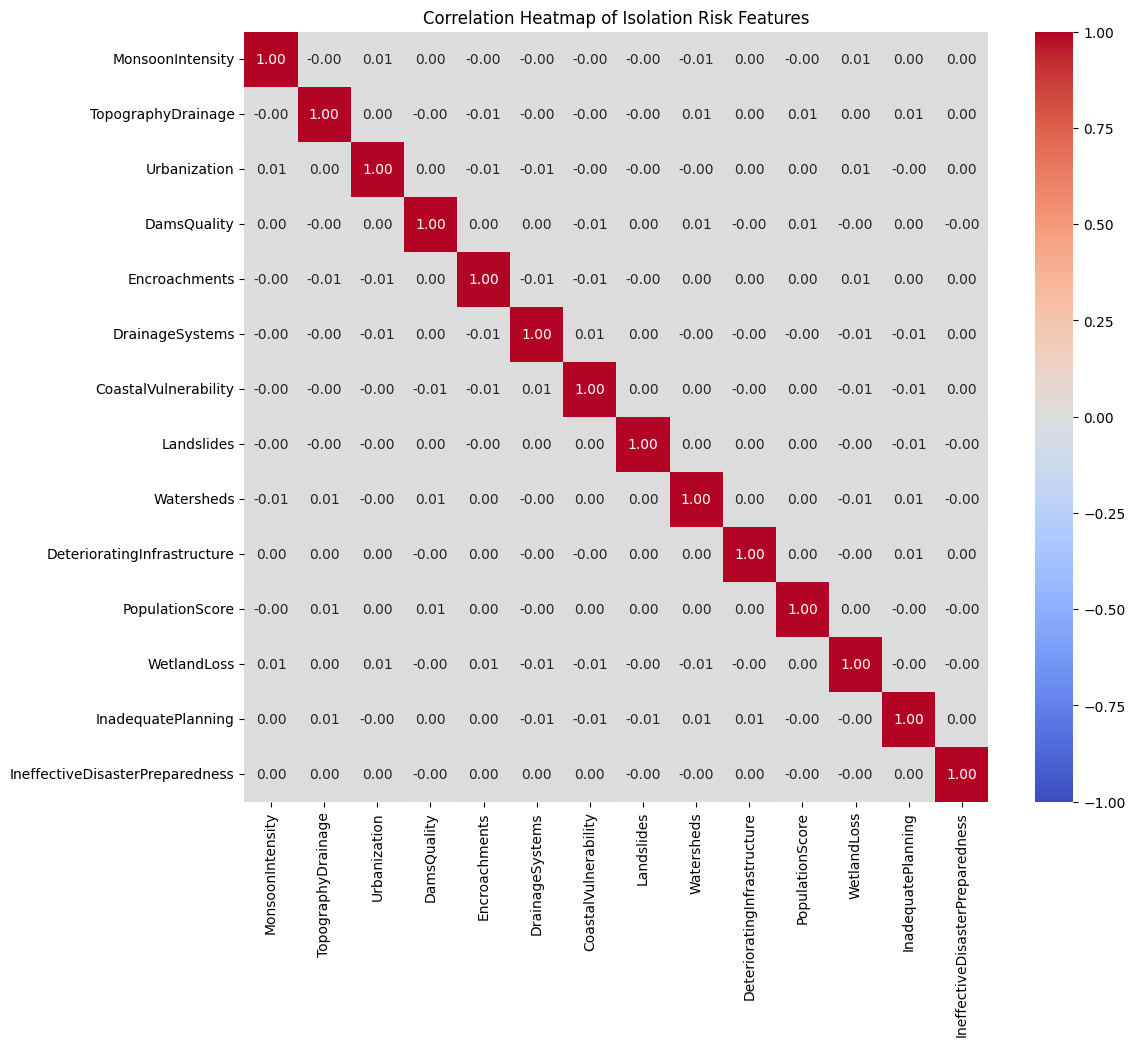

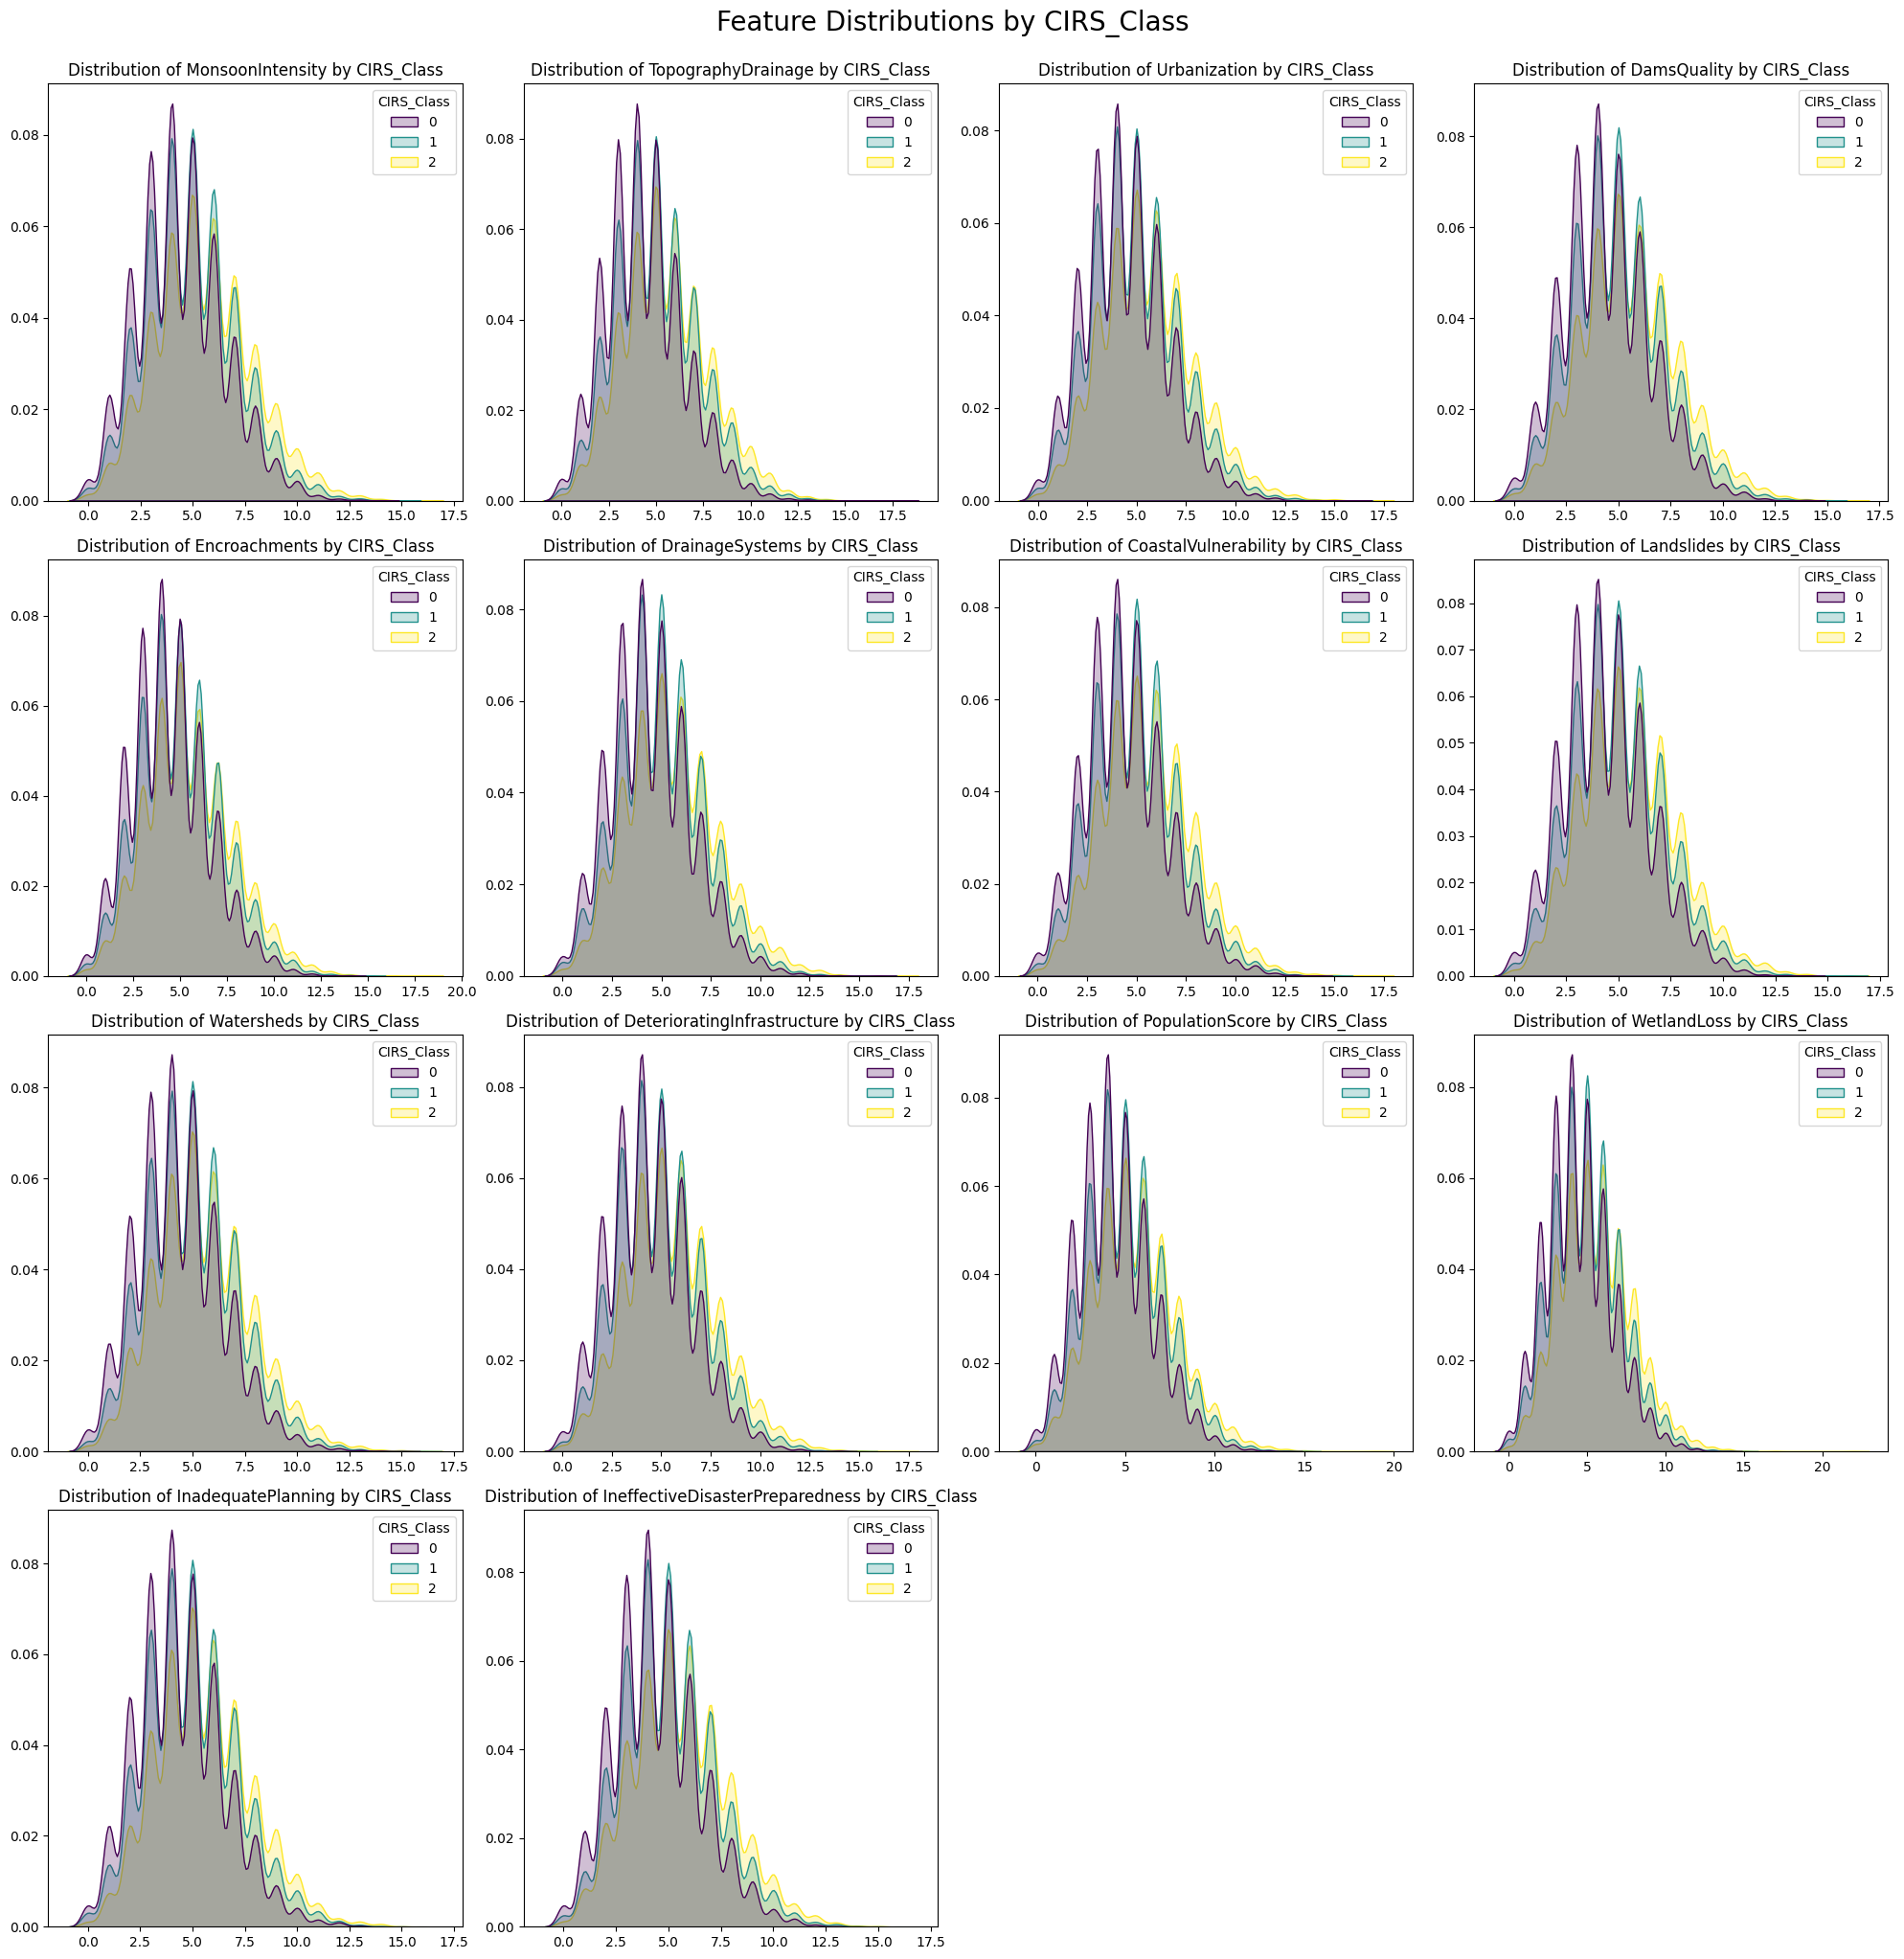

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# STEP 3 — Exploratory Visualisations

# Figure — Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df_filtered[selected_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Isolation Risk Features')
plt.savefig('correlation_heatmap.png')
plt.show()

# Figure — Feature Distributions by Class
num_features = len(selected_features)
num_rows = 4
num_cols = 4 # 14 plots, so 4x4 grid will leave 2 unused

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 20))
axes = axes.flatten() # Flatten the 4x4 array of axes for easy iteration

for i, feature in enumerate(selected_features):
    sns.kdeplot(data=df_filtered, x=feature, hue='CIRS_Class', fill=True, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature} by CIRS_Class')
    axes[i].set_xlabel('') # Clear x-label to avoid clutter
    axes[i].set_ylabel('') # Clear y-label

# Hide unused subplots
for j in range(num_features, num_rows * num_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Feature Distributions by CIRS_Class', y=1.02, fontsize=20)
plt.savefig('feature_distributions_by_class.png')
plt.show()

/tmp/ipykernel_6735/3137704204.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.loc[:, 'CIRS_Class'] = df_filtered['FloodProbability'].apply(assign_cirs_class)


Low/Medium Boundary (33.33rd percentile): 0.4750
Medium/High Boundary (66.67th percentile): 0.5200

CIRS_Class distribution:
CIRS_Class
0    16691
1    17298
2    16011
Name: count, dtype: int64

CIRS_Class percentage distribution:
CIRS_Class
0    0.33382
1    0.34596
2    0.32022
Name: proportion, dtype: float64


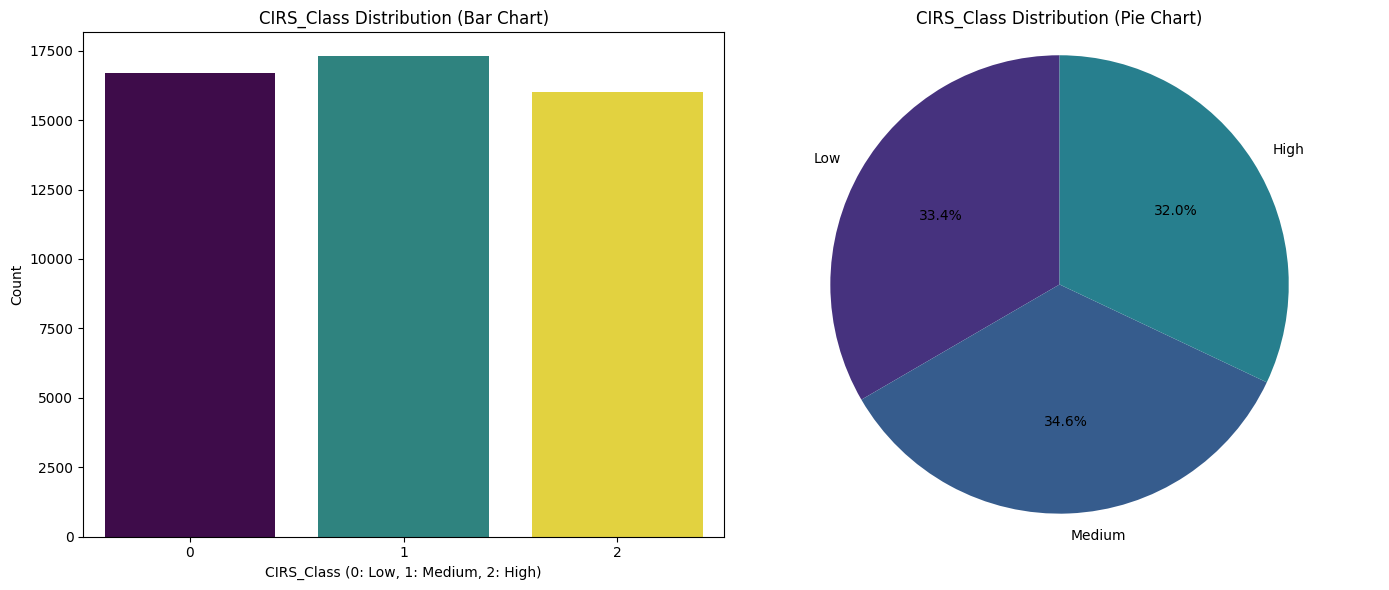

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 2 — Target Variable Construction

# Calculate tertile boundaries
low_medium_boundary = df_filtered['FloodProbability'].quantile(0.3333)
medium_high_boundary = df_filtered['FloodProbability'].quantile(0.6667)

# Assign CIRS_Class based on tertile boundaries
def assign_cirs_class(prob):
    if prob <= low_medium_boundary:
        return 0  # Low
    elif prob <= medium_high_boundary:
        return 1  # Medium
    else:
        return 2  # High

df_filtered.loc[:, 'CIRS_Class'] = df_filtered['FloodProbability'].apply(assign_cirs_class)

# Print the thresholds and class balance
print(f"Low/Medium Boundary (33.33rd percentile): {low_medium_boundary:.4f}")
print(f"Medium/High Boundary (66.67th percentile): {medium_high_boundary:.4f}")
print("\nCIRS_Class distribution:")
print(df_filtered['CIRS_Class'].value_counts().sort_index())
print("\nCIRS_Class percentage distribution:")
print(df_filtered['CIRS_Class'].value_counts(normalize=True).sort_index())

# Generate and save two class distribution plots
plt.figure(figsize=(14, 6))

# Bar Chart
plt.subplot(1, 2, 1)
sns.countplot(x='CIRS_Class', hue='CIRS_Class', data=df_filtered, palette='viridis', legend=False)
plt.title('CIRS_Class Distribution (Bar Chart)')
plt.xlabel('CIRS_Class (0: Low, 1: Medium, 2: High)')
plt.ylabel('Count')

# Pie Chart
plt.subplot(1, 2, 2)
class_counts = df_filtered['CIRS_Class'].value_counts(sort=False)
plt.pie(class_counts, labels=['Low', 'Medium', 'High'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis'))
plt.title('CIRS_Class Distribution (Pie Chart)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show()

In [ ]:
import pandas as pd

# STEP 1 — Load and Filter Data

# Load flood.csv into a dataframe
df = pd.read_csv('/content/flood.csv')

# Define the 14 features to use
selected_features = [
    'MonsoonIntensity', 'TopographyDrainage', 'Urbanization', 'DamsQuality',
    'Encroachments', 'DrainageSystems', 'CoastalVulnerability', 'Landslides',
    'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
    'InadequatePlanning', 'IneffectiveDisasterPreparedness'
]

# Add the target variable to the list of columns to keep
columns_to_keep = selected_features + ['FloodProbability']

# Keep only the selected features plus FloodProbability
df_filtered = df[columns_to_keep]

# Print the shape, all column names, full .describe() output, and missing value counts
print(f"Shape after filtering: {df_filtered.shape}")
print("\nColumn names:")
print(df_filtered.columns.tolist())
print("\nDescriptive statistics:")
print(df_filtered.describe())
print("\nMissing value counts:")
print(df_filtered.isnull().sum())

Shape after filtering: (50000, 15)

Column names:
['MonsoonIntensity', 'TopographyDrainage', 'Urbanization', 'DamsQuality', 'Encroachments', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'IneffectiveDisasterPreparedness', 'FloodProbability']

Descriptive statistics:
       MonsoonIntensity  TopographyDrainage  Urbanization  DamsQuality  \
count      50000.000000        50000.000000  50000.000000  50000.00000   
mean           4.991480            4.984100      4.989060      5.01536   
std            2.236834            2.246488      2.243159      2.24500   
min            0.000000            0.000000      0.000000      0.00000   
25%            3.000000            3.000000      3.000000      3.00000   
50%            5.000000            5.000000      5.000000      5.00000   
75%            6.000000            6.000000      6.000000      6.00000   
max           16.000000      